## Import Libraries and Load data

In [1]:
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
DATA_PATH= './../data'

In [13]:
main_df = pd.read_csv(os.path.join(DATA_PATH,'CNA_SV.csv'))
main_df.head()

,Unnamed: 0,9-Sep_SV,A2BP1_SV,AASDH_SV,AATF_SV,AATK_SV,AATK-AS1_SV,ABCA1_SV,ABCA12_SV,ABCA13_SV,...,TSC2_CNA,TSHR_CNA,U2AF1_CNA,VHL_CNA,WT1_CNA,XPO1_CNA,ZRSR2_CNA,SEX,AGE_AT_SEQ_REPORT,CANCER_TYPE
0,GENIE-DFCI-000024-4434,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female,87,Esophagogastric Cancer
1,GENIE-DFCI-000027-10441,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,Female,74,Soft Tissue Sarcoma
2,GENIE-DFCI-000029-10065,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,Male,63,Renal Cell Carcinoma
3,GENIE-DFCI-000029-526237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,Male,65,Renal Cell Carcinoma
4,GENIE-DFCI-000035-11184,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Female,67,CNS Cancer


## Data Preprocessing

In [9]:
df_CNA_SV = main_df[main_df['CANCER_TYPE'] != 'Cancer of Unknown Primary']
test_df = main_df[main_df['CANCER_TYPE'] == 'Cancer of Unknown Primary']


# Filter based on cancer types with more than 1000 instances
cancer_count = df_CNA_SV['CANCER_TYPE'].value_counts()
selected_cancer_types = cancer_count[cancer_count.values > 1000].index.to_list()
df_CNA_SV = df_CNA_SV[df_CNA_SV['CANCER_TYPE'].isin(selected_cancer_types)].reset_index(drop=True)

# Drop columns with zero variation
zero_variation_col = []
for col in df_CNA_SV.columns:
    if len(df_CNA_SV[col].unique()) <= 1:
        zero_variation_col.append(col)


df = df_CNA_SV.copy()
df=df.drop(['Unnamed: 0']+zero_variation_col,axis=1).reset_index(drop=True)

In [10]:
## Label encode cancer types
label_encoder_cancer = LabelEncoder()
df['CANCER_TYPE'] = label_encoder_cancer.fit_transform(df['CANCER_TYPE'])

In [14]:
#Remove low correlated features
import pickle

with open(os.path.join(DATA_PATH,'specific_column_corr.pickle'), 'rb') as handle:
    specific_column_corr_loaded = pickle.load(handle)

unselected_features=[col for col in df.columns if col not in specific_column_corr_loaded.index.to_list()]

df=df.drop(unselected_features,axis=1).reset_index(drop=True)
df.shape

(16493, 207)

In [15]:
X_test =test_df.drop(['Unnamed: 0','CANCER_TYPE'] + zero_variation_col+unselected_features,axis=1).reset_index(drop=True)
X_test.shape

(821, 206)

In [16]:
# Split the data into features and target
X = df.drop(columns=['CANCER_TYPE'])
y = df['CANCER_TYPE']

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [17]:
#Data transformation

label_encoder_sex = LabelEncoder()
X_train['SEX'] = label_encoder_sex.fit_transform(X_train[['SEX']])

scaler = StandardScaler()
X_train['AGE_AT_SEQ_REPORT'] = scaler.fit_transform(X_train[['AGE_AT_SEQ_REPORT']])

X_val['SEX'] = label_encoder_sex.transform(X_val['SEX'])
X_val['AGE_AT_SEQ_REPORT'] = scaler.transform(X_val[['AGE_AT_SEQ_REPORT']])


X_test['SEX'] = label_encoder_sex.transform(X_test['SEX'])
X_test['AGE_AT_SEQ_REPORT'] = scaler.transform(X_test[['AGE_AT_SEQ_REPORT']])

/home/afiibnat/miniconda3/envs/Ls_env/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [18]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
#test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
#test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Model Training

In [21]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model initialization
input_dim = X_train.shape[1]
output_dim = len(df['CANCER_TYPE'].unique())

In [22]:
import torch.nn.functional as F

class DeepCNA(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DeepCNA, self).__init__()
        self.fc_layers = nn.Sequential(
            nn.Linear(input_dim, 768),
            nn.BatchNorm1d(768),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(768, 384),
            nn.BatchNorm1d(384),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(384, 192),
            nn.BatchNorm1d(192),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(192, 96),
            nn.BatchNorm1d(96),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(96, output_dim)
        )
        self._initialize_weights()

    def forward(self, x):
        return self.fc_layers(x)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)



model = DeepCNA(input_dim, output_dim).to(device)

In [23]:
def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, patience=5, max_epochs=100):
    train_losses = []
    val_losses = []
    best_val_loss = np.inf
    epochs_no_improve = 0
    best_model = None
    
    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
        
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
        
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        
        print(f'Epoch [{epoch+1}/{max_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}')
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_model = model
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f'Early stopping after {epoch+1} epochs.')
                break
        
        scheduler.step()
    
    return best_model, train_losses, val_losses




In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# Train the model with early stopping
best_model, train_losses, val_losses = train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, patience=30, max_epochs=100)

Epoch [1/100], Train Loss: 1.5676, Val Loss: 1.0803
Epoch [2/100], Train Loss: 1.1588, Val Loss: 0.9784
Epoch [3/100], Train Loss: 1.0485, Val Loss: 0.9433
Epoch [4/100], Train Loss: 0.9986, Val Loss: 0.9255
Epoch [5/100], Train Loss: 0.9500, Val Loss: 0.9151
Epoch [6/100], Train Loss: 0.9184, Val Loss: 0.9033
Epoch [7/100], Train Loss: 0.8943, Val Loss: 0.8997
Epoch [8/100], Train Loss: 0.8607, Val Loss: 0.8930
Epoch [9/100], Train Loss: 0.8464, Val Loss: 0.8879
Epoch [10/100], Train Loss: 0.8352, Val Loss: 0.8891
Epoch [11/100], Train Loss: 0.8372, Val Loss: 0.8842
Epoch [12/100], Train Loss: 0.8239, Val Loss: 0.8838
Epoch [13/100], Train Loss: 0.8254, Val Loss: 0.8835
Epoch [14/100], Train Loss: 0.8257, Val Loss: 0.8825
Epoch [15/100], Train Loss: 0.8155, Val Loss: 0.8812
Epoch [16/100], Train Loss: 0.8110, Val Loss: 0.8805
Epoch [17/100], Train Loss: 0.8159, Val Loss: 0.8820
Epoch [18/100], Train Loss: 0.8069, Val Loss: 0.8824
Epoch [19/100], Train Loss: 0.8107, Val Loss: 0.8816
Ep

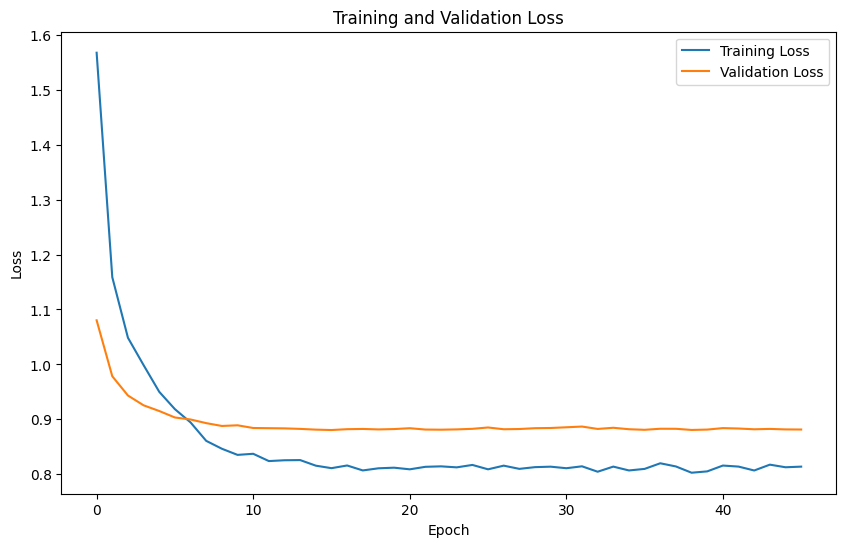

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
# plt.savefig("./data/training_validation_loss_right_fit.png",bbox_inches = 'tight')
plt.show()

In [26]:
# Evaluation mode
best_model.eval()

# Function to calculate accuracy
def calculate_accuracy(loader, model):
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

train_accuracy = calculate_accuracy(train_loader, best_model)
test_accuracy = calculate_accuracy(val_loader, best_model)

print(f'Train Accuracy: {train_accuracy:.2f}%')
print(f'Validation Accuracy: {test_accuracy:.2f}%')


Train Accuracy: 75.69%
Validation Accuracy: 67.66%


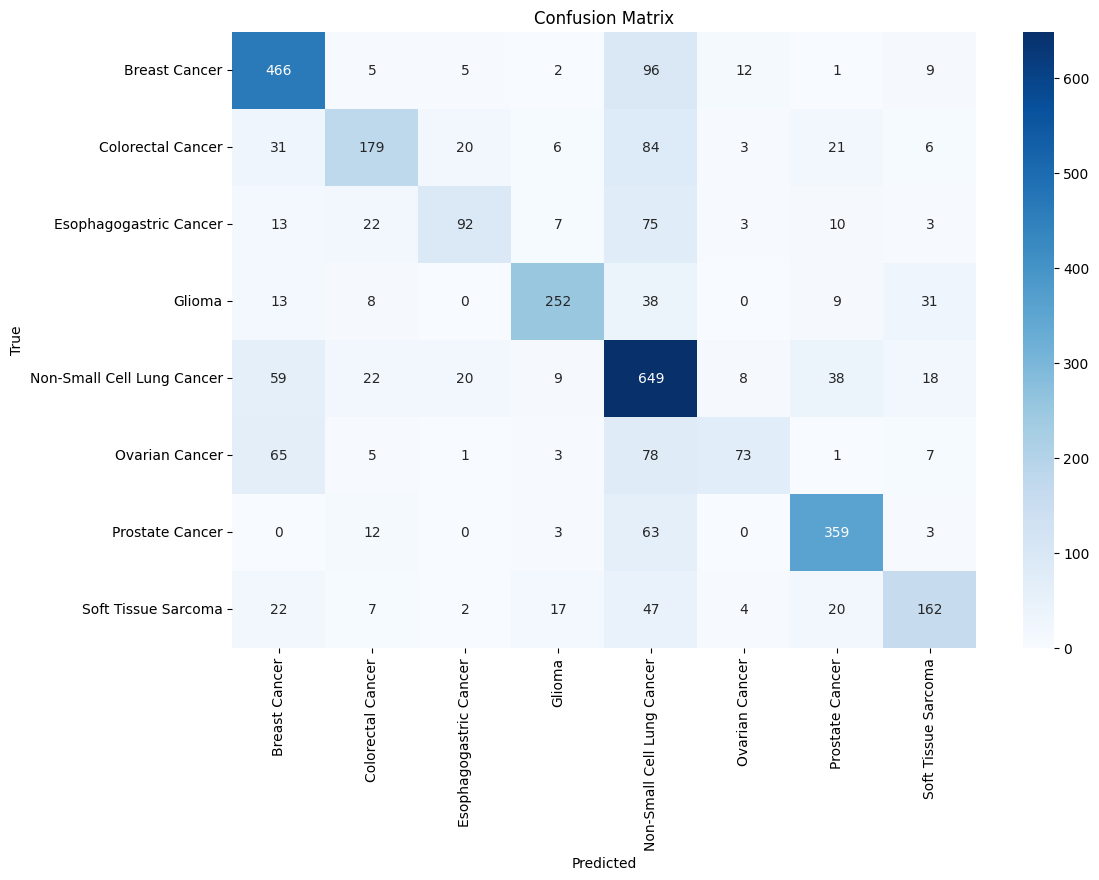

                            precision    recall  f1-score   support

             Breast Cancer       0.70      0.78      0.74       596
         Colorectal Cancer       0.69      0.51      0.59       350
    Esophagogastric Cancer       0.66      0.41      0.50       225
                    Glioma       0.84      0.72      0.78       351
Non-Small Cell Lung Cancer       0.57      0.79      0.66       823
            Ovarian Cancer       0.71      0.31      0.43       233
           Prostate Cancer       0.78      0.82      0.80       440
       Soft Tissue Sarcoma       0.68      0.58      0.62       281

                  accuracy                           0.68      3299
                 macro avg       0.70      0.61      0.64      3299
              weighted avg       0.69      0.68      0.67      3299



In [27]:
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
y_val_pred = []
y_val_true = []

best_model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        y_val_pred.extend(predicted.cpu().numpy())
        y_val_true.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_cancer.classes_, yticklabels=label_encoder_cancer.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
# plt.savefig("./data/confusion_matrix_right_fit.png",bbox_inches = 'tight')
plt.show()

# Classification Report
print(classification_report(y_val_true, y_val_pred, target_names=label_encoder_cancer.classes_))


In [28]:
# Get cancer of unknown primary predictions
y_test_pred = []


best_model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        y_test_pred.extend(predicted.cpu().numpy())

## Feature Importance Analysis

In [25]:
import shap
# Convert data to numpy arrays
X_train_np = X_train.values
X_test_np = X_test.values

# Initialize the SHAP DeepExplainer
explainer = shap.DeepExplainer(best_model, torch.tensor(X_train_np, dtype=torch.float32).to(device))

In [15]:
from tqdm import tqdm
from joblib import Parallel, delayed

# Define function to compute SHAP values for a subset of data with progress bar
def compute_shap_values_with_progress(data_subset):
    return explainer.shap_values(torch.tensor(data_subset, dtype=torch.float32).to(device))

# Split data into chunks (adjust chunk size based on available memory)
chunk_size = 100
num_chunks = len(X_test_np) // chunk_size
chunks = [X_test_np[i*chunk_size:(i+1)*chunk_size] for i in range(num_chunks)]

# Compute SHAP values in parallel with progress bar
shap_values_chunks = []
for chunk in tqdm(chunks, desc="Processing chunks", total=len(chunks)):
    shap_values_chunks.append(compute_shap_values_with_progress(chunk))


Processing chunks: 100%|██████████| 8/8 [37:25<00:00, 280.68s/it]


In [26]:
# with open('shap_values.pkl','wb') as f:
#     pickle.dump(shap_values_chunks, f)

In [30]:
import pickle
with open(os.path.join(DATA_PATH,'shap_values.pkl'),'rb') as f:
    shap_values = pickle.load(f)

In [31]:
combined_shap_values = np.concatenate(shap_values, axis=0)

In [26]:
with torch.no_grad():
    y_test_predictions = best_model(torch.tensor(X_test_np, dtype=torch.float32).to(device)).argmax(dim=1).cpu().numpy()

In [30]:
shap_values_np=shap_values
average_shap_values = {}

# Iterate over each class (third dimension in shap_values_np)
for class_index in range(combined_shap_values.shape[2]):
    
    # Extract SHAP values for the current class
    class_shap_values = combined_shap_values[:, :, class_index]
    
    # Create a DataFrame to store SHAP values and their corresponding predictions
    shap_df = pd.DataFrame(class_shap_values, columns=X.columns)
    shap_df['predicted_class'] = y_test_predictions[:800]

    # Filter SHAP values for instances predicted as the current class
    class_shap_df = shap_df[shap_df['predicted_class'] == class_index]

    # Calculate average SHAP values for the current class
    class_avg_shap_values = class_shap_df.drop(columns=['predicted_class']).mean()

    # Store the average SHAP values for the current class
    class_name=label_encoder_cancer.inverse_transform([class_index])[0]
    average_shap_values[f'{class_name}'] = class_avg_shap_values

# Convert the average SHAP values to a DataFrame for better visualization
average_shap_values_df = pd.DataFrame(average_shap_values)

average_shap_values_df.to_csv('shape_explanation.csv')

In [73]:
average_shap_values_df= pd.read_csv('shape_explanation.csv')
average_shap_values_df.head()

,Unnamed: 0,Breast Cancer,Colorectal Cancer,Esophagogastric Cancer,Glioma,Non-Small Cell Lung Cancer,Ovarian Cancer,Prostate Cancer,Soft Tissue Sarcoma
0,AGO2_SV,0.000138,-0.000266,-0.000577,0.000754,-0.000467,0.000283,0.000141,0.000249
1,ALK_SV,0.008871,0.011909,0.002515,0.009221,0.004023,0.005723,0.007590,0.002794
2,AR_SV,0.000991,0.000663,0.000837,0.000136,0.000527,0.001030,-0.003380,-0.000506
3,ARID1B_SV,-0.003873,0.000752,0.000200,0.000244,0.000579,-0.000283,0.000446,0.000229
4,ARRDC4_SV,-0.000175,0.000018,0.000077,0.000042,0.000015,-0.000016,0.000117,-0.000018


#### Preprocessing shap values

In [74]:
average_shap_values_df=average_shap_values_df.set_index('Unnamed: 0')
cancer_types=average_shap_values_df.columns
cancer_types

Index(['Breast Cancer', 'Colorectal Cancer', 'Esophagogastric Cancer',
       'Glioma', 'Non-Small Cell Lung Cancer', 'Ovarian Cancer',
       'Prostate Cancer', 'Soft Tissue Sarcoma'],
      dtype='object')

In [75]:
fetaure_type=average_shap_values_df.reset_index()['Unnamed: 0'].apply(lambda x: categorize_feature(x))
average_shap_values_df['feature_type']=fetaure_type.values.tolist()
average_shap_values_df.head()

,Breast Cancer,Colorectal Cancer,Esophagogastric Cancer,Glioma,Non-Small Cell Lung Cancer,Ovarian Cancer,Prostate Cancer,Soft Tissue Sarcoma,feature_type
Unnamed: 0,,,,,,,,,
AGO2_SV,0.000138,-0.000266,-0.000577,0.000754,-0.000467,0.000283,0.000141,0.000249,Somatic Mutation
ALK_SV,0.008871,0.011909,0.002515,0.009221,0.004023,0.005723,0.007590,0.002794,Somatic Mutation
AR_SV,0.000991,0.000663,0.000837,0.000136,0.000527,0.001030,-0.003380,-0.000506,Somatic Mutation
ARID1B_SV,-0.003873,0.000752,0.000200,0.000244,0.000579,-0.000283,0.000446,0.000229,Somatic Mutation
ARRDC4_SV,-0.000175,0.000018,0.000077,0.000042,0.000015,-0.000016,0.000117,-0.000018,Somatic Mutation


In [80]:
palette = {
    'Somatic Mutation': 'blue',
    'CNA events': 'green',
    'Age': 'grey',
    'Sex': 'red'
}


def categorize_feature(feature_name):
    if feature_name.endswith('_SV'):
        return 'Somatic Mutation'
    elif feature_name.endswith('_CNA'):
        return 'CNA events'
    elif feature_name=='AGE_AT_SEQ_REPORT':
        return 'Age'
    elif feature_name=='SEX':
        return 'Sex'
    else:
        return 'Other'


# Define a function to plot SHAP values
def plot_shap_values(shap_values_df,label, title="SHAP Values"):
    plt.figure(figsize=(10, 6))
    sorted_df=class_shap_values.reset_index().sort_values(by=label,key=abs,ascending=False)[:10]
    sns.barplot(x=label, y='Unnamed: 0', data=sorted_df, hue='feature_type', dodge=False, palette=palette)
    plt.title(title)
    plt.xlabel("SHAP Value")
    plt.ylabel("Feature")
    plt.legend(title="Feature Groups", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"./Shap_values_CUP/{label}.jpeg")
    plt.show()

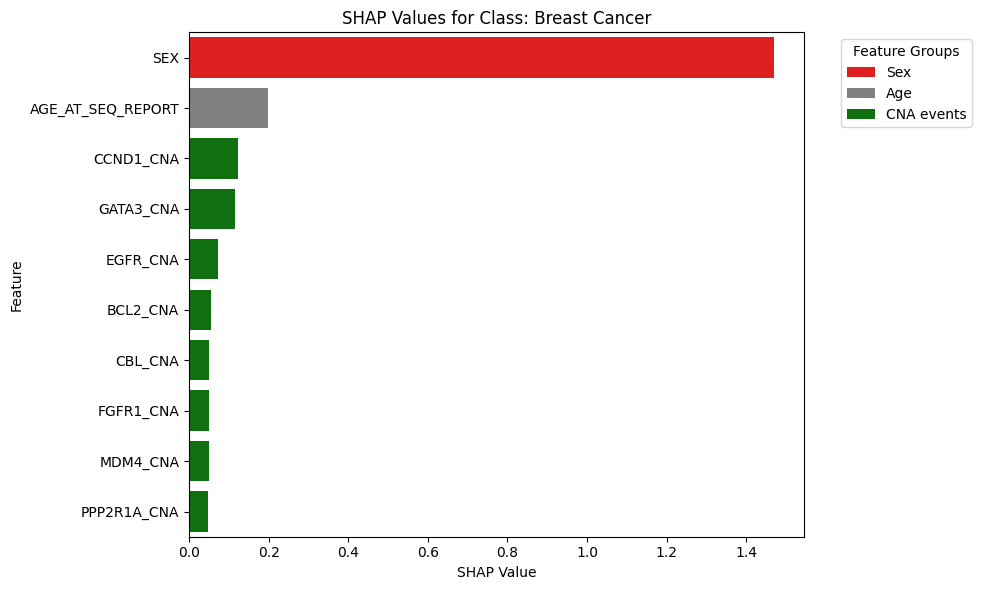

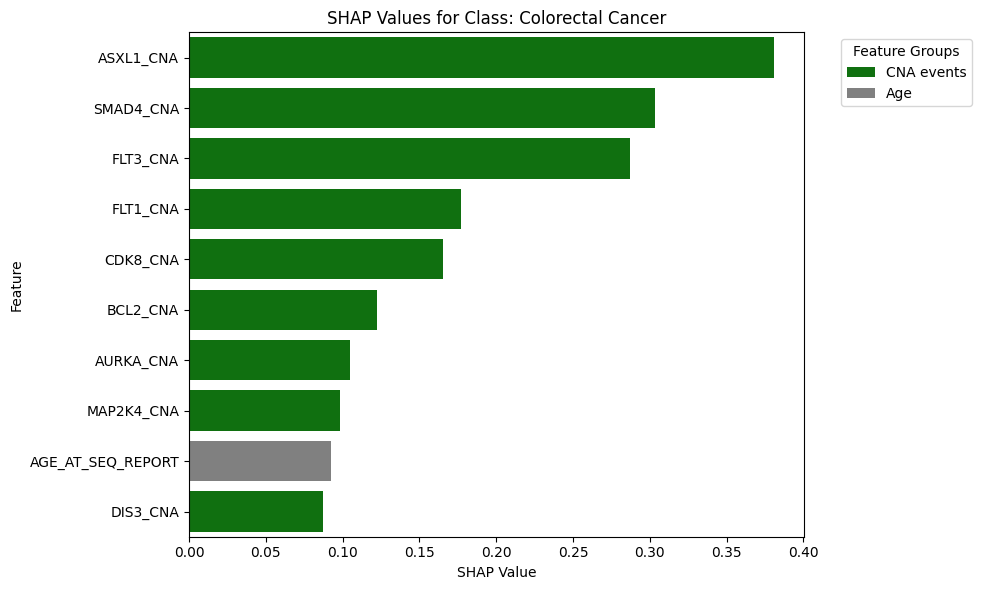

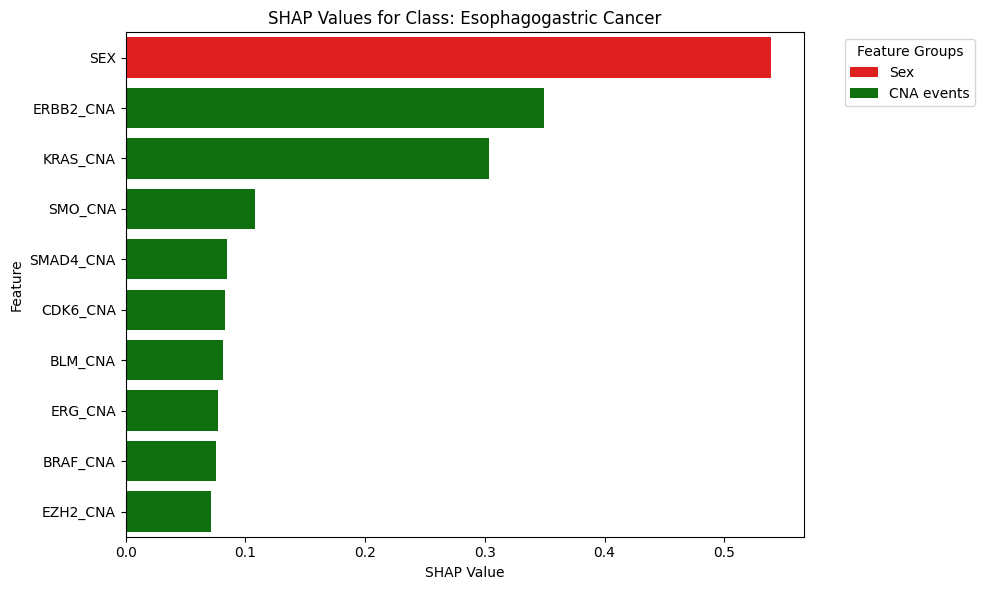

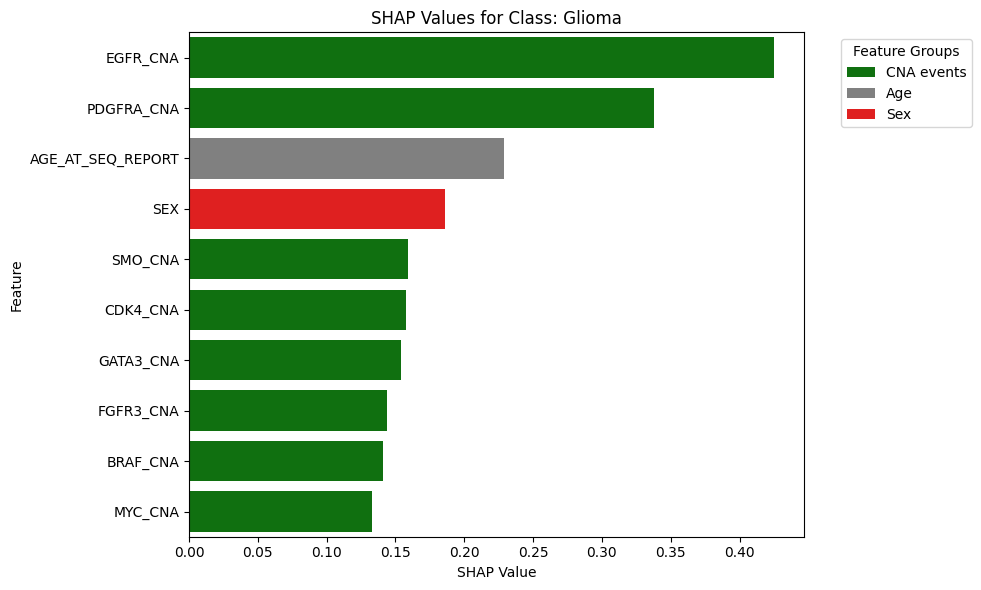

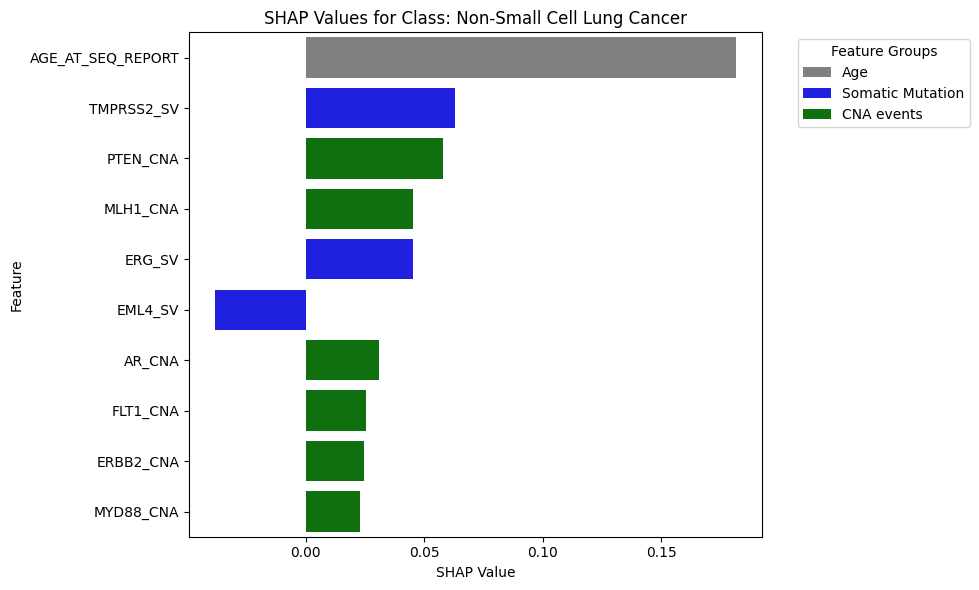

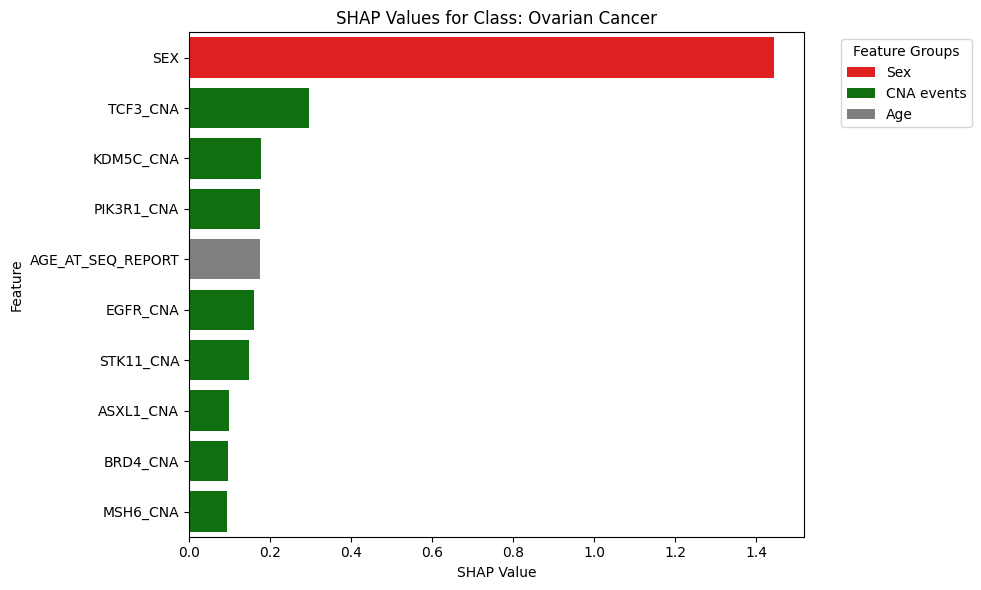

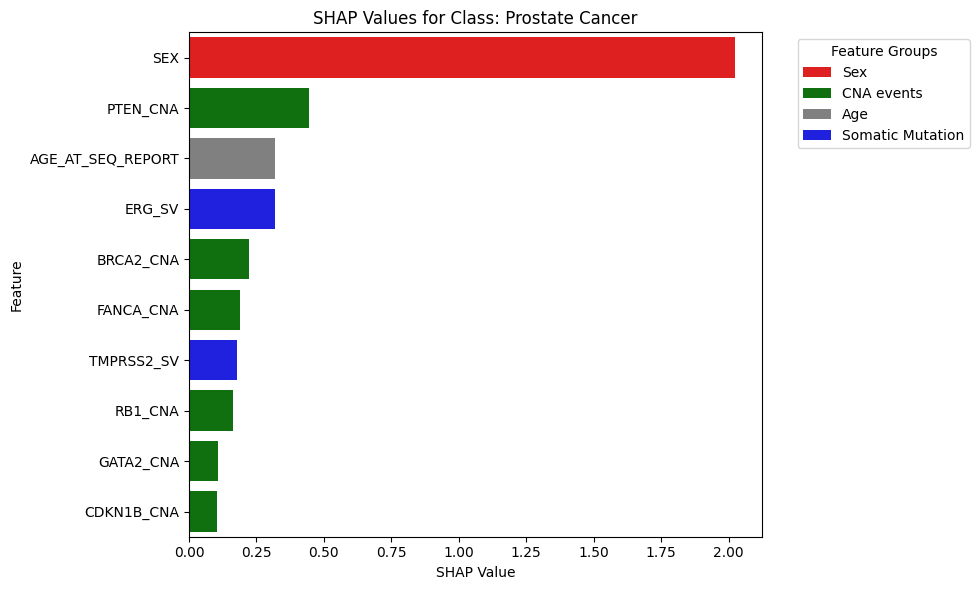

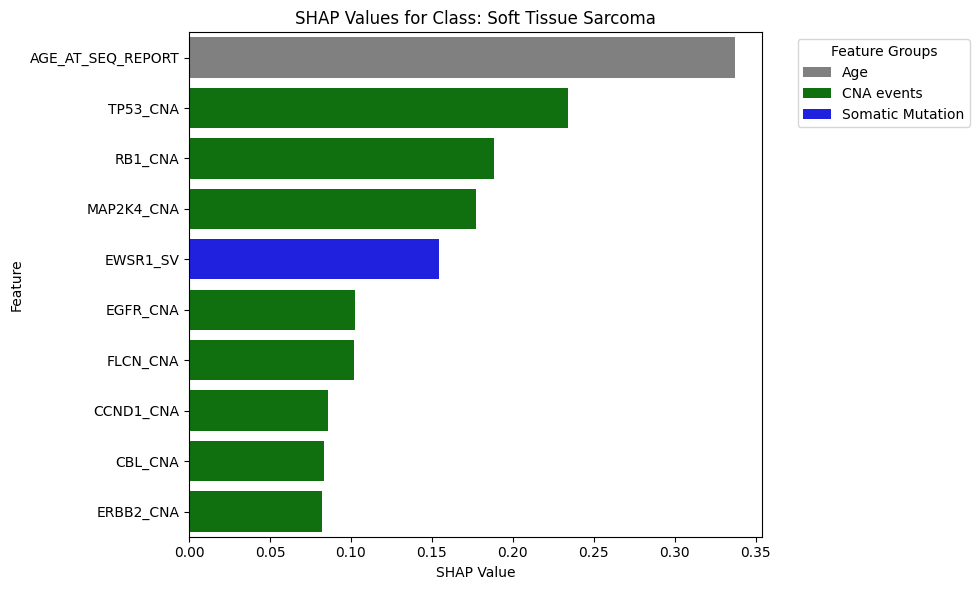

In [81]:
# Now plot for each class
for class_name in cancer_types:
    class_shap_values = average_shap_values_df[[class_name]+['feature_type']]
    plot_shap_values(class_shap_values, label=class_name,title=f"SHAP Values for Class: {class_name}")